W1 shape: (12288, 256)


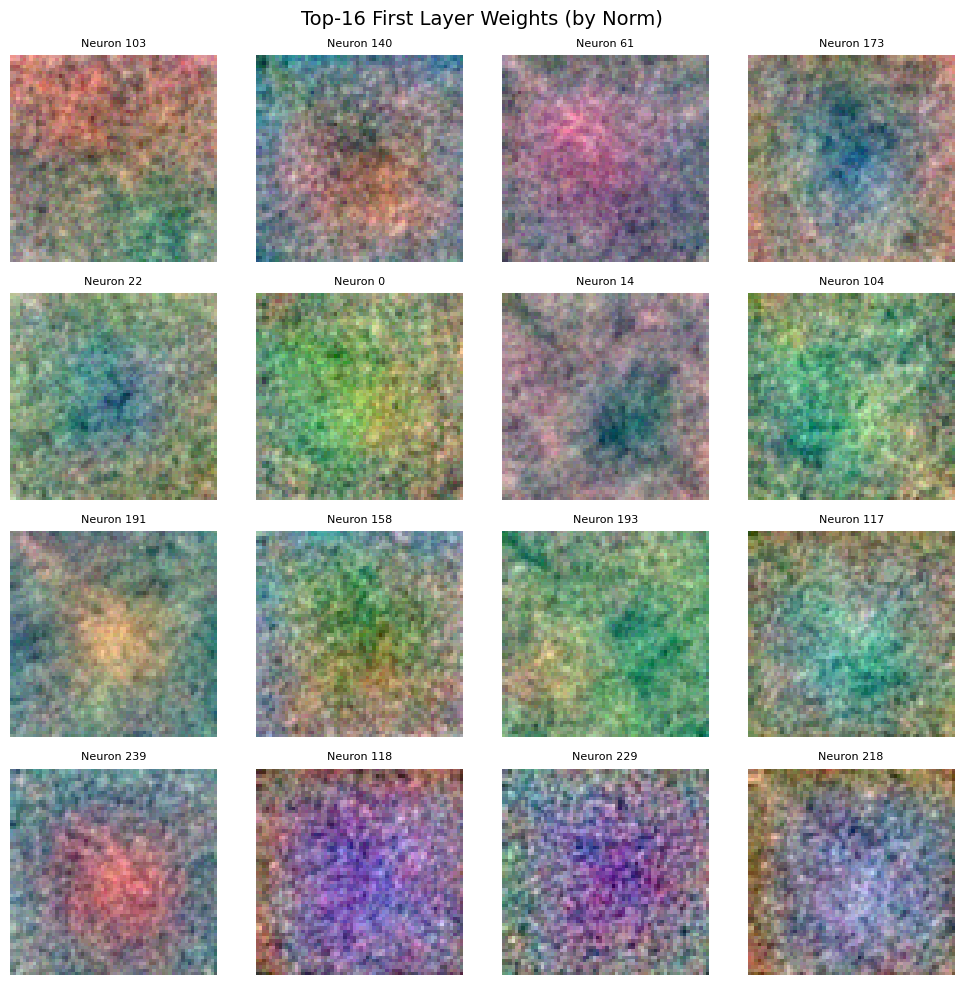

In [8]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

# ====== 1. load model ======
model_path = '../output/experiment_20260412_123429/checkpoints/best_model.pkl'

with open(model_path, 'rb') as f:
    checkpoint = pickle.load(f)

W1 = checkpoint['params']['W1']   # (12288, 256)

print("W1 shape:", W1.shape)

img_size = 64
hidden_size = W1.shape[1]

# ====== 2. 选“最重要”的 neuron（不是前16个） ======
norms = np.linalg.norm(W1, axis=0)
top_indices = np.argsort(norms)[-16:]   # 选权重最大的16个

# ====== 3. 可视化 ======
plt.figure(figsize=(10, 10))

for i, idx in enumerate(top_indices):
    w = W1[:, idx]

    # reshape 成图像
    w_img = w.reshape(img_size, img_size, 3)

    # ====== ⭐关键：保留正负信息 ======
    max_val = np.abs(w_img).max()
    w_img = w_img / (max_val + 1e-8)   # [-1,1]
    w_img = (w_img + 1) / 2            # -> [0,1]

    plt.subplot(4, 4, i + 1)
    plt.imshow(w_img)
    plt.title(f"Neuron {idx}", fontsize=8)
    plt.axis('off')

plt.suptitle("Top-16 First Layer Weights (by Norm)", fontsize=14)
plt.tight_layout()
# plt.show()
plt.savefig("first_layer_weights_top16.png")